In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.interpolate import interp1d
import scipy.sparse.linalg as spla
import scipy.sparse as sp

In [5]:
def solve_pressure(u, dx, dt, rho):

    N = len(u)-1
    A = np.zeros((N,N))
    b = np.zeros(N) #second membre de l'equation

    coef = dt/(rho*dx**2) #
    for i in range(1, N-1):
        A[i,i] = -2*coef
        if i>0:
            A[i,i-1] = coef
        if i<N-1:
            A[i,i+1] = coef


# Condition de Neumann aux bords pour la pression
    A[0,0] = -coef
    A[0, 1] = coef
    A[N-1,N-1] = -coef
    A[N-1, N-2] = coef

    for i in range(N):
        b[i] = (u[i+1] - u[i])/dx

#Gestion de la singularité de la matrice A (non-inversible): On va fixer la pression p1 = 0 
#Donc la première ligne de A sera [1, 0, ..., 0] et la première composante de b sera 0

    A[0, :] = 0.
    A[0, 0] = coef
    b[0] = 0.

    p = np.linalg.solve(A, b)

    return p

In [6]:
# u[j] correspond à u_{j+1/2}^n
# u[j-1] correspond à u_{j-1/2}^n
# u[j+1] correspond à u_{j+3/2}^n

In [7]:
def NS(xv, xp, u0, p0,  T, dt_init, nu, rho, u_top, alpha = 1., beta = 1.):
    """
    Résout l'équation de Navier-Stokes 1d par la méthode de prédiction correction
    Paramètres:
    xv : array--> Points du maillage spatial pour la vitesse (interfaces des cellules) taille N+1
    xp : array --> Points du maillage spatial pour la pression (centres des cellules)
    u0 : array--> vitesse initiale
    p0 : array --> pression initiale
    T : Temps final de simulation
    dt_init : Pas de temps initial
    nu: Viscosité
    rho: Densité

    Retourne:
    u : array Solution (discrète) au temps T
    p : array Solution (discrète) au temps T
"""
    N = len(xp) # Nombre de cellules pression
    u = np.copy(u0) # Taille N+1, calculé aux interfaces des cellules
    p = np.copy(p0) # Taille N, calculé aux centres
    dx = xv[1]-xv[0] # Pas d'espace


    t= 0 # Temps initial
    k=0 # pour compter le nombre d'itérations
    while t<T:

        # Calcul du pas de temps adaptatif (condition CFL)
        dt_viscous = 0.25*dx**2/(nu+1e-10)

        max_u_abs = np.max(np.abs(u))
        if max_u_abs < 1e-9:
             dt_convective = dt_viscous * 10 # Effectively large if no flow
        else:
            dt_convective = 0.4*dx / max_u_abs

        dt = min(dt_init, dt_convective, dt_viscous)
        
        if dt <= 1e-12 : # Prevent dt from becoming too small if dt_init is tiny
            dt = dt_viscous # Fallback to viscous CFL if dt gets stuck too small
            if dt_init > 0 : dt = min(dt, dt_init)


        if t+dt > T:
            dt = T-t
            if dt <= 1e-9 * T: # Avoid extremely small final step relative to T
                break


        
        #calcul des flux pour le terme convectif (flux upwind)
        flux = np.zeros(N+1)
        for i in range(N+1):
            if i==0:
                u_gauche = u[0] #u_{-1/2} inconnue est traité comme u_{1/2}

                flux[i] = 0.5*(u_gauche**2)


            elif i==N:
                u_gauche = u[i-1] #u_{N-1/2}
                u_droite = u[i]#u_{N+1/2}
            
                if 0.5*(u_gauche + u_droite) >= 0:
                    flux[i] = 0.5*(u_gauche**2)       
                else:
                    flux[i] = 0.5*(u_droite**2)

                    
            else:
                u_gauche = u[i-1]
                u_droite = u[i]

                if 0.5*(u_gauche + u_droite) >= 0:
                    flux[i] = 0.5*(u_gauche**2)
                else:
                    flux[i] = 0.5*(u_droite**2)

                
        #Étape1: Prediction de la vitesse
        u_star = np.copy(u)
        ##faire le calcul de u_star par l'équation de quantité de mouvement        
        for j in range(1, N):
            u_star[j] = u[j] - beta*(dt/dx)*(flux[j+1]-flux[j]) - alpha*(dt/(rho*dx))*(p[j]-p[j-1]) + (nu*dt/dx**2)*(u[j+1]-2*u[j]+u[j-1])

        # Conditions de Dirichlet aux bords
        u_star[0] = 0
        u_star[N] = u_top

        #Étape2: Correction
        
        #Faire le calcul de la pression afin que le champ de vitesse final soit à divergence-libre

        p_new = solve_pressure(u_star, dx, dt, rho)




        u_new = np.copy(u_star)
        for j in range(1, N):
            u_new[j] = u_star[j] - alpha*(dt/(rho*dx))*(p_new[j]-p_new[j-1])

        # Conditions de Dirichlet aux bords
        u_new[0] = 0
        u_new[N] = u_top

        
        #mise à jour
        p = p_new
        u = u_new
        t+=dt
        k+=1


    print("Nb. iter : ", k)

    return u, p


In [8]:
N = 3
A = np.zeros((N,N))

for i in range(1, N-1):
    A[i,i] = -2
    if i>0:
        A[i,i-1] = 1 
    if i<N-1:
        A[i,i+1] = 1


# A[0,0] = -1
# A[0, 1] = 1
# A[N-1,N-1] = 1
# A[N-1, N-2] = -1
print(A)

[[ 0.  0.  0.]
 [ 1. -2.  1.]
 [ 0.  0.  0.]]


In [17]:
#################### Test Écoulement Couette ######################################""
#L’écoulement Couette est le mouvement d’un fluide visqueux entre deux plaques parallèles,
#  dont l’une est en mouvement uniforme (à vitesse constante) et l’autre est immobile.
# Pas de convection, ni de gradient de pression, en régime stationnaire on obtient u(x, t)= u_top*x/L


L = 1.
rho = 1.
nu = 0.1
u_top = 1. #vitesse de la plaque du haut

N = 50
T_vals = [0, 0.5, 1, 2, 5]
dt_init = 1e-3
dx = L/N
xv = np.linspace(0, L, N+1)
xp = np.linspace(dx/2, L-dx/2, N)

#fluide au repos u(x, 0) = 0
#pression initiale p(x, 0) = 0
u0 = np.zeros(N+1)
p0 = np.zeros(N)

#conditions aux bords (vitesse)
u0[0] = 0
u0[-1] = u_top


In [18]:
# beta = 1.
# alpha = 0.
# for T in T_vals:
#     u, _ = NS(xv, xp, u0, p0,  T, dt_init, nu, rho, u_top, alpha, beta)
#     plt.plot(xv, u, '--', label=f"t ={T}")

# plt.plot(xv, xv/L * u_top, '-', label='Profil de vitesse stable (analytique)') # Solution analytique à long terme
# plt.xlabel('Position x (m)')
# plt.ylabel('Vitesse u (m/s)')
# plt.title(f"Écoulement de Couette - alpha = {alpha} beta = {beta}")
# plt.legend()
# plt.grid(True)
# plt.show()

Nb. iter :  0
Nb. iter :  500
Nb. iter :  1000
Nb. iter :  2000
Nb. iter :  5001


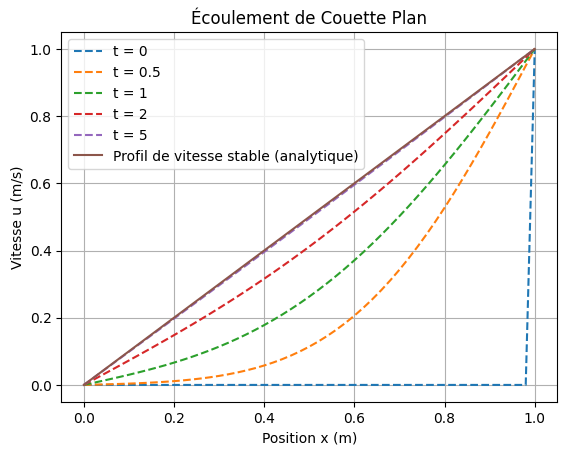

In [19]:
beta = 0.
alpha = 0.
for T in T_vals:
    u, _ = NS(xv, xp, u0, p0,  T, dt_init, nu, rho, u_top, alpha, beta)
    plt.plot(xv, u, '--', label=f"t = {T}")

plt.plot(xv, xv/L * u_top, '-', label='Profil de vitesse stable (analytique)') # Solution analytique à long terme
plt.xlabel('Position x (m)')
plt.ylabel('Vitesse u (m/s)')
plt.title(f"Écoulement de Couette Plan")
plt.legend()
plt.grid(True)
plt.savefig('ecoulement de couette plan.png')
plt.show()

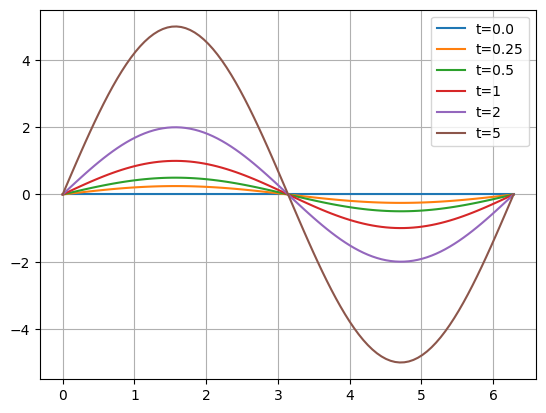

In [16]:
x = np.linspace(0, 2*np.pi, 100)
t_vals = [0., 0.25, 0.5, 1, 2, 5]
for t in t_vals:
    plt.plot(x, t*np.sin(x), label=f"t={t}")

plt.legend()
plt.grid()
plt.show()

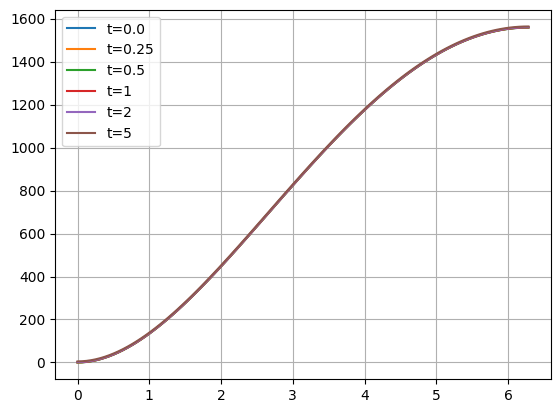

In [117]:
x = np.linspace(0, 2*np.pi, 100)
t_vals = [0., 0.25, 0.5, 1, 2, 5]
for t in t_vals:
    plt.plot(x, (x**2-4*x*np.pi)**2 +t, label=f"t={t}")

plt.legend()
plt.grid()
plt.show()

Ordre de convergence

In [ ]:
def step1(xv, xp, u0, p0, T, dt_init, nu, rho, L, f, alpha =1.):
    """
    On se donne une fonction pour la pression, une solution exacte de l'équation de quantité de mouvement u, et on construit un second membre f
    On appliquera des condtions aux bords de type Dirichlet
    """

    N = len(xp) # Nombre de cellules pression
    u = np.copy(u0) # Taille N+1, calculé aux interfaces des cellules
    p = np.copy(p0) # Taille N, calculé aux centres
    dx = xv[1]-xv[0] # Pas d'espace


    t= 0 # Temps initial
    k=0 # pour compter le nombre d'itérations
    while t<T:

        # Calcul du pas de temps adaptatif (condition CFL)
        dt_viscous = 0.25*dx**2/(nu+1e-10)

        max_u_abs = np.max(np.abs(u))
        if max_u_abs < 1e-9:
             dt_convective = dt_viscous * 10 # Effectively large if no flow
        else:
            dt_convective = 0.4*dx / max_u_abs

        dt = min(dt_init, dt_convective, dt_viscous)
        
        if dt <= 1e-12 : # Prevent dt from becoming too small if dt_init is tiny
            dt = dt_viscous # Fallback to viscous CFL if dt gets stuck too small
            if dt_init > 0 : dt = min(dt, dt_init)


        if t+dt > T:
            dt = T-t
            if dt <= 1e-9 * T: # Avoid extremely small final step relative to T
                break

        
        #calcul des flux pour le terme convectif (flux upwind)
        flux = np.zeros(N+1)
        for i in range(N+1):
            if i==0:
                flux[i] = 0.5*u[0]**2

            elif i==N:
                u_gauche = u[i-1] #u_{N-1/2}
                u_droite = u[i]#u_{N+1/2}
            
                if 0.5*(u_gauche + u_droite) >= 0:
                    flux[i] = 0.5*(u_gauche**2)       
                else:
                    flux[i] = 0.5*(u_droite**2)
                    
            else:
                u_gauche = u[i-1]
                u_droite = u[i]

                if 0.5*(u_gauche + u_droite) >= 0:
                    flux[i] = 0.5*(u_gauche**2)
                else:
                    flux[i] = 0.5*(u_droite**2)

                
        #Étape1: Prediction de la vitesse
        u_star = np.copy(u)
        ##faire le calcul de u_star par l'équation de quantité de mouvement        
        for j in range(1, N):
            u_star[j] = u[j] - (dt/dx)*(flux[j+1]-flux[j]) - (dt/(rho*dx))*(p[j]-p[j-1]) + (nu*dt/dx**2)*(u[j+1]-2*u[j]+u[j-1]) + dt*f(xv[j], t, nu, rho) #avec second membre

        # Conditions de Dirichlet aux bords
        u_star[0] = 0.
        u_star[N] = L*alpha


        u = u_star
        t+=dt
        k+=1


    print("Nb. iter : ", k)

    return u

In [14]:
def u_ex(x, t):
    return t*np.sin(x)

def p_ex(x, t):
    return  (x*(x-4*np.pi))**2 +t

def f(x, t, nu, rho):
    return np.sin(x)+t**2*np.sin(x)*np.cos(x) + nu*t*np.sin(x) + (4/rho)*x*(x-2*np.pi)*(x-4*np.pi)

In [4]:
def u_ex1(x, t):
    return x

def p_ex1(x, t):
    return -10*x

def f1(x, t, nu, rho):
    return x - 10./rho

In [5]:
L = 2*np.pi
rho = 1.
nu = 1.

N = 100
dt_init = 1e-3
T_vals = [1.]
dx = L/N
xv = np.linspace(0, L, N+1)
xp = np.linspace(dx/2, L-dx/2, N)


Nb. iter :  1014


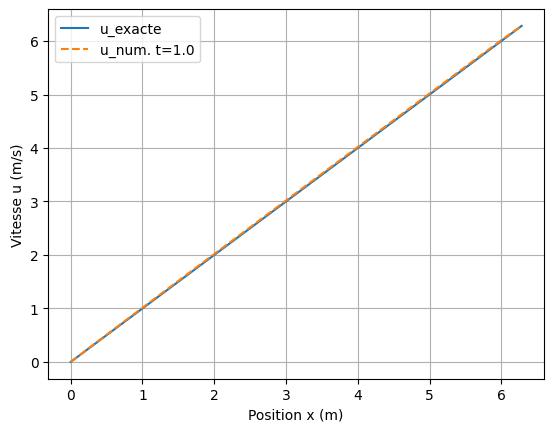

In [6]:
u0 = u_ex1(xv, 0)
p0 = p_ex1(xp, 0)
for T in T_vals:
    u_num = step1(xv, xp, u0, p0, T, dt_init, nu, rho, L, f1)
    plt.plot(xv, u_ex1(xv, T), '-', label=f"u_exacte")
    plt.plot(xv, u_num, '--', label=f"u_num. t={T}")
plt.xlabel('Position x (m)')
plt.ylabel('Vitesse u (m/s)')
plt.legend()
plt.grid()
plt.show()

Pour écoulement de couette

Nb. iter :  1014
Nb. iter :  2027


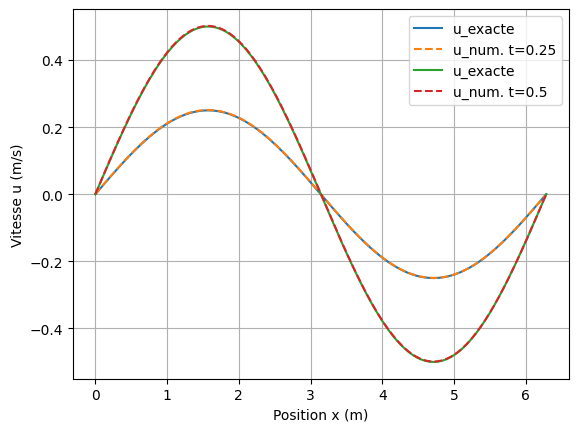

In [7]:
L = 2*np.pi
rho = 1.
nu = 1

N = 200
dt_init = 1e-3
T_vals = [0.25, 0.5]
dx = L/N
xv = np.linspace(0, L, N+1)
xp = np.linspace(dx/2, L-dx/2, N)


u0 = u_ex(xv, 0)
p0 = p_ex(xp, 0)
alpha = 0.
for T in T_vals:
    u_num = step1(xv, xp, u0, p0, T, dt_init, nu, rho, L, f, alpha)
    plt.plot(xv, u_ex(xv, T), '-', label=f"u_exacte")
    plt.plot(xv, u_num, '--', label=f"u_num. t={T}")
plt.xlabel('Position x (m)')
plt.ylabel('Vitesse u (m/s)')
plt.legend()
plt.grid()
plt.show()

Nb. iter :  507
Nb. iter :  2027
Nb. iter :  8106
Nb. iter :  32423
Ordre de convergence estimé avec dt = 0.001 : 1.89


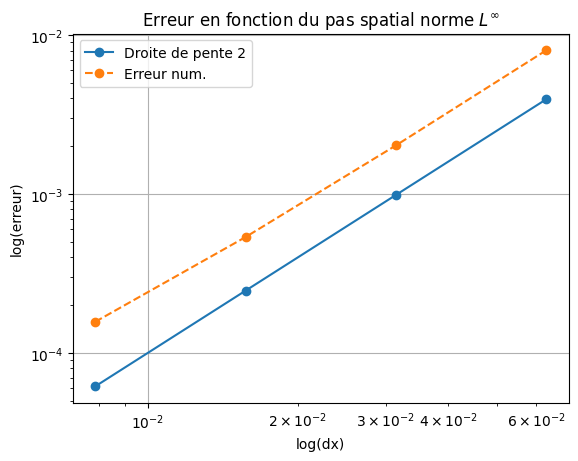

In [13]:
T = 0.5
L = 2*np.pi
rho = 1.
nu = 1
alpha =0.
dt = 1e-3


N_vals = [100, 200, 400, 800]
dx_vals_N = []
erreurs_N = []

for N in N_vals:
    xv = np.linspace(0, L, N+1)
    dx = xv[1]-xv[0]
    dx_vals_N.append(dx)
    xp = np.linspace(dx/2, L-dx/2, N)


    u0 = u_ex(xv, 0.)
    p0 = p_ex(xp, 0.)
    un = step1(xv, xp, u0, p0, T, dt, nu, rho, L, f, alpha)
    u_exN = u_ex(xv, T)
    err = np.linalg.norm(u_exN - un, np.inf)
    erreurs_N.append(err)



log_erreurs_N = np.log(erreurs_N)
log_dx = np.log(dx_vals_N)

pente1, _ = np.polyfit(log_dx, log_erreurs_N, 1)

print(f"Ordre de convergence estimé avec dt = {dt} : {pente1:.2f}")



plt.loglog(dx_vals_N, np.array(dx_vals_N)**2, 'o-', label ="Droite de pente 2")
plt.loglog(dx_vals_N, erreurs_N, 'o--', label = "Erreur num.")
plt.title(r"Erreur en fonction du pas spatial norme $L^{\infty}$")
plt.xlabel("log(dx)")
plt.ylabel("log(erreur)")
plt.legend()
plt.grid()
plt.show()

In [11]:
print(erreurs_N)

[np.float64(0.008023278862166583), np.float64(0.0020233488165699587), np.float64(0.0005364647159414038), np.float64(0.00015719263836611042)]


Ordre 2 en espace: 
Cause possible: dominance du terme visqueux

Nb. iter :  500
Nb. iter :  500
Nb. iter :  500
Nb. iter :  500
Ordre de convergence estimé avec dt = 0.001 : 1.74


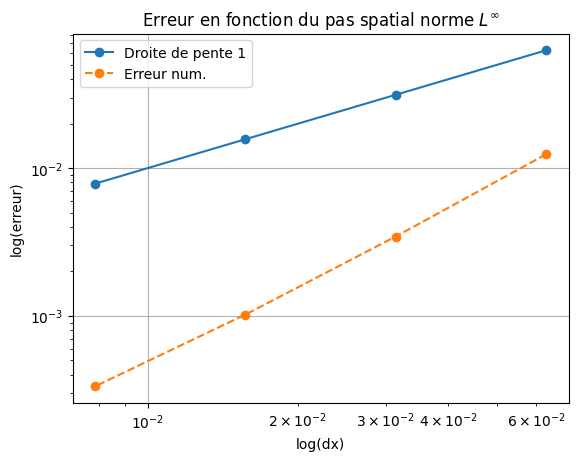

In [22]:
T = 0.5
L = 2*np.pi
rho = 1.
nu = 1e-5
alpha =0.
dt = 1e-3


N_vals = [100, 200, 400, 800]
dx_vals_N = []
erreurs_N = []

for N in N_vals:
    xv = np.linspace(0, L, N+1)
    dx = xv[1]-xv[0]
    dx_vals_N.append(dx)
    xp = np.linspace(dx/2, L-dx/2, N)


    u0 = u_ex(xv, 0.)
    p0 = p_ex(xp, 0.)
    un = step1(xv, xp, u0, p0, T, dt, nu, rho, L, f, alpha)
    u_exN = u_ex(xv, T)
    err = np.linalg.norm(u_exN - un, np.inf)
    erreurs_N.append(err)



log_erreurs_N = np.log(erreurs_N)
log_dx = np.log(dx_vals_N)

pente1, _ = np.polyfit(log_dx, log_erreurs_N, 1)

print(f"Ordre de convergence estimé avec dt = {dt} : {pente1:.2f}")



plt.loglog(dx_vals_N, dx_vals_N, 'o-', label ="Droite de pente 1")
plt.loglog(dx_vals_N, erreurs_N, 'o--', label = "Erreur num.")
plt.title(r"Erreur en fonction du pas spatial norme $L^{\infty}$")
plt.xlabel("log(dx)")
plt.ylabel("log(erreur)")
plt.legend()
plt.grid()
plt.show()

L'ordre de convergence diminue lorque l'on prend une viscosité plus petite, et tend vers 1 lorsque dx ->0

Convergence en temps

In [80]:
T = 0.5
L = 2*np.pi
rho = 1.
nu = 1e-2
alpha =0.

N = 500
dx = L/N
xv = np.linspace(0, L, N+1)
xp = np.linspace(dx/2, L-dx/2, N)
u0 = u_ex(xv, 0) #condition initiale
p0 = p_ex(xp, 0)
u_e = u_ex(xv, T)


dt_vals = [1e-7, 1e-5, 1e-3, 1e-1]

vals_erreurLinf = []

for dt in dt_vals:
    u = step1(xv, xp, u0, p0, T, dt, nu, rho, L, f, alpha)
    
    erreur = u - u_e
    vals_erreurLinf.append(np.max(np.abs(erreur)))


log_dt = np.log(dt_vals)
log_erreurLinf = np.log(vals_erreurLinf)

pente, _ = np.polyfit(log_dt, log_erreurLinf, 1)
print(f"Ordre de convergence en temps estimé: {pente:.2f}")



# Ajout de la pente d'ordre 1
dt_vals = np.array(dt_vals)
plt.loglog(dt_vals, dt_vals, marker='o', label="Pente d'ordre 1")

plt.loglog(dt_vals, vals_erreurLinf, marker='o', label="Erreur numérique")
plt.xlabel("log(dt)")
plt.ylabel("log(erreur)")
plt.title('Erreur en fonction du pas de temps')
plt.legend()
plt.grid()   
plt.show()

KeyboardInterrupt: 

In [11]:
def solve_pressure2(u, xp, t, dt, rho, f):

    N = len(xp)
    A = np.zeros((N,N))
    b = np.zeros(N) #second membre de l'equation

    dx = xp[1]-xp[0]
    coef = dt/(rho*dx**2)
    for i in range(1, N-1):
        A[i,i] = -2*coef
        if i>0:
            A[i,i-1] = coef
        if i<N-1:
            A[i,i+1] = coef


# Condition de Neumann aux bords pour la pression
    A[0,0] = -coef
    A[0, 1] = coef
    A[N-1,N-1] = -coef
    A[N-1, N-2] = coef

    for i in range(N):
        b[i] = (u[i+1] - u[i])/dx  + f(xp[i], t, dt, rho)


#Gestion de la singularité de la matrice A (non-inversible): On va fixer la pression p1 = 0 
#Donc la première ligne de A sera [1, 0, ..., 0] et la première composante de b sera 0

    A[0, :] = 0.
    A[0, 0] = coef
    b[0] = 0.

    p = np.linalg.solve(A, b)

    return p

In [ ]:
def step2(xv, xp, u, p0, T, dt, rho, f):    
    N = len(u)-1
    A = np.zeros((N,N))
    b = np.zeros(N) #second membre de l'equation

    coef = dt/(rho*dx**2) #
    for i in range(1, N-1):
        A[i,i] = -2*coef
        if i>0:
            A[i,i-1] = coef
        if i<N-1:
            A[i,i+1] = coef


# Condition de Neumann aux bords pour la pression
    A[0,0] = -coef
    A[0, 1] = coef
    A[N-1,N-1] = -coef
    A[N-1, N-2] = coef

    for i in range(N):
        b[i] = (u[i+1] - u[i])/dx

#Gestion de la singularité de la matrice A (non-inversible): On va fixer la pression p1 = 0 
#Donc la première ligne de A sera [1, 0, ..., 0] et la première composante de b sera 0

    A[0, :] = 0.
    A[0, 0] = coef
    b[0] = 0.

    p = np.linalg.solve(A, b)

    return p
    """
    On se donne une fonction pour la vitesse, une solution exacte p de l'équation de conservation de la masse, et on construit un second membre f
    On appliquera des condtions aux bords de type Neumann homogène
    """

    u_star = u(xv, 0.)# u Taille N+1, calculé aux interfaces des cellules
    p = np.copy(p0) # Taille N, calculé aux centres


    t= 0 # Temps initial
    k=0 # pour compter le nombre d'itérations
    while t<T:

        if t+dt > T:
            dt = T-t


        p_new = solve_pressure2(u_star, xp, t, dt, rho, f)

        p = p_new
        t+=dt
        u_star = u(xv, t)
        k+=1


    print("Nb. iter : ", k)

    return p

In [69]:
def fp(x, t, dt, rho):
    return (dt/rho)*4*(3*x**2 -12*np.pi*x + 8*np.pi**2) +t*np.cos(x)

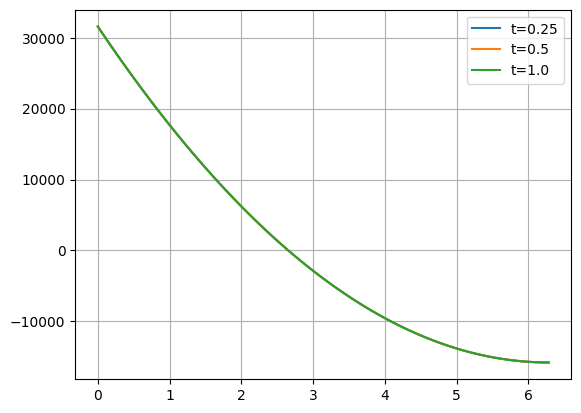

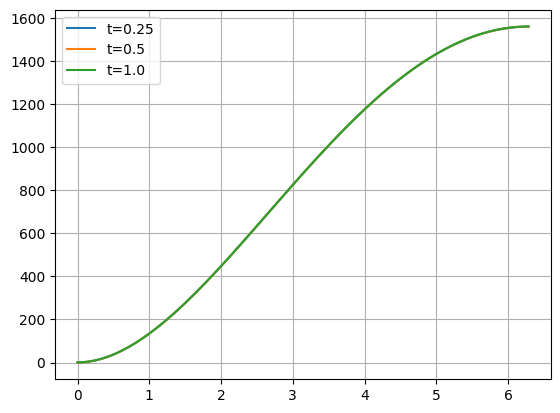

In [70]:
rho = 1e-3
t_vals = [0.25, 0.5, 1.]
dt = 0.1
x = np.linspace(0, 2*np.pi, 100)
for t in t_vals:
    plt.plot(x, fp(x, t, dt, rho), label=f"t={t}")

plt.legend()
plt.grid()
plt.show()

for t in t_vals:
    plt.plot(x, p_ex(x, t), label=f"t={t}")

plt.legend()
plt.grid()
plt.show()

0.2
0.4
0.5
Nb. iter :  3


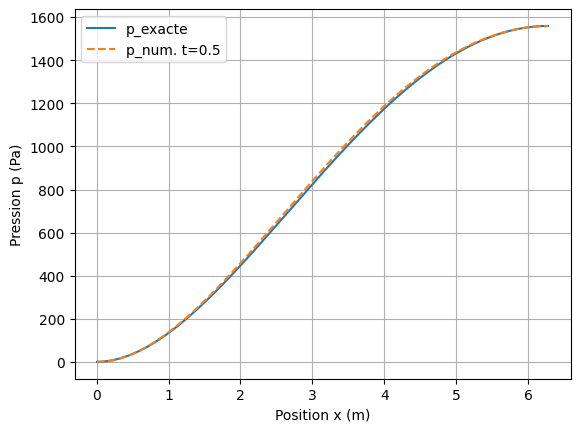

In [75]:
L = 2*np.pi
rho = 1.

N = 500
dt = 0.2
T_vals = [0.5]
dx = L/N
xv = np.linspace(0, L, N+1)
xp = np.linspace(dx/2, L-dx/2, N)



p0 = p_ex(xp, 0)
alpha = 0.
for T in T_vals:
    p_num = step2(xv, xp, u_ex, p0, T, dt, rho, fp)
    plt.plot(xp, p_ex(xp, T), '-', label=f"p_exacte")
    plt.plot(xp, p_num, '--', label=f"p_num. t={T}")
plt.xlabel('Position x (m)')
plt.ylabel('Pression p (Pa)')
plt.legend()
plt.grid()
plt.show()